# Prueba Microcredencial Gestión de Carteras con Python
26/03/2026

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
import missingno as mso
import cvxpy as cp
import statsmodels.api as sm
from pandas_datareader import data as pdr

## Ejercicio 1
Descarga de datos y análisis inicial.

In [2]:
tickers = [
    "VTI",  # Vanguard Total Stock Market (Mercado total EE.UU.)
    "QQQ",  # Invesco QQQ Trust (Tecnología Nasdaq 100)
    "BTC-USD",  # Bitcoin (Activo de riesgo/liquidez global)
    "ASML",  # ASML Holding (Semiconductores, ciclo de innovación)
    "XWD.TO",  # iShares MSCI World ETF (Renta variable global)
    "GLD",  # SPDR Gold Shares  (Oro, refugio de valor)
    "USO",  # United States Oil Fund, LP (Petróleo, energía)
    "AGZD",  # WisdomTree Interest Rate Hedged U.S. Aggregate Bond Fund (Cobertura de tipos)
    "DBA",  # Invesco DB Agriculture Fund (Materias primas agrícolas)
    "VNQ",  # Vanguard Real Estate Index Fund ETF Shares (Bienes raíces)
    "SH",  # ProShares Short S&P500 (Inverso del mercado)
    "VXX",  # iPath Series B S&P 500 VIX Short-Term Futures ETN (Volatilidad/Miedo)
    "TLT",  # iShares 20+ Year Treasury Bond ETF (Bonos largo plazo)
    "PSQ",  # ProShares Short QQQ (Inverso de tecnología)
]
data = yf.download(tickers, start = "2016-01-01", end = "2026-03-25",multi_level_index= False, auto_adjust= False)["Adj Close"]

[*********************100%***********************]  14 of 14 completed


In [411]:
tickers = ["SPY"]
data_idx = yf.download(tickers,  start = "2016-01-01", end = "2026-03-25",multi_level_index= False, auto_adjust= False)["Adj Close"]


[*********************100%***********************]  1 of 1 completed


Visualización rápida de los precios.

<Axes: xlabel='Date'>

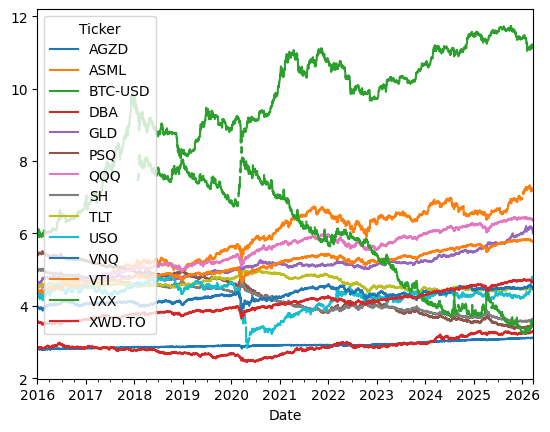

In [4]:
np.log(data).plot()

Visualización de datos faltantes

<Axes: >

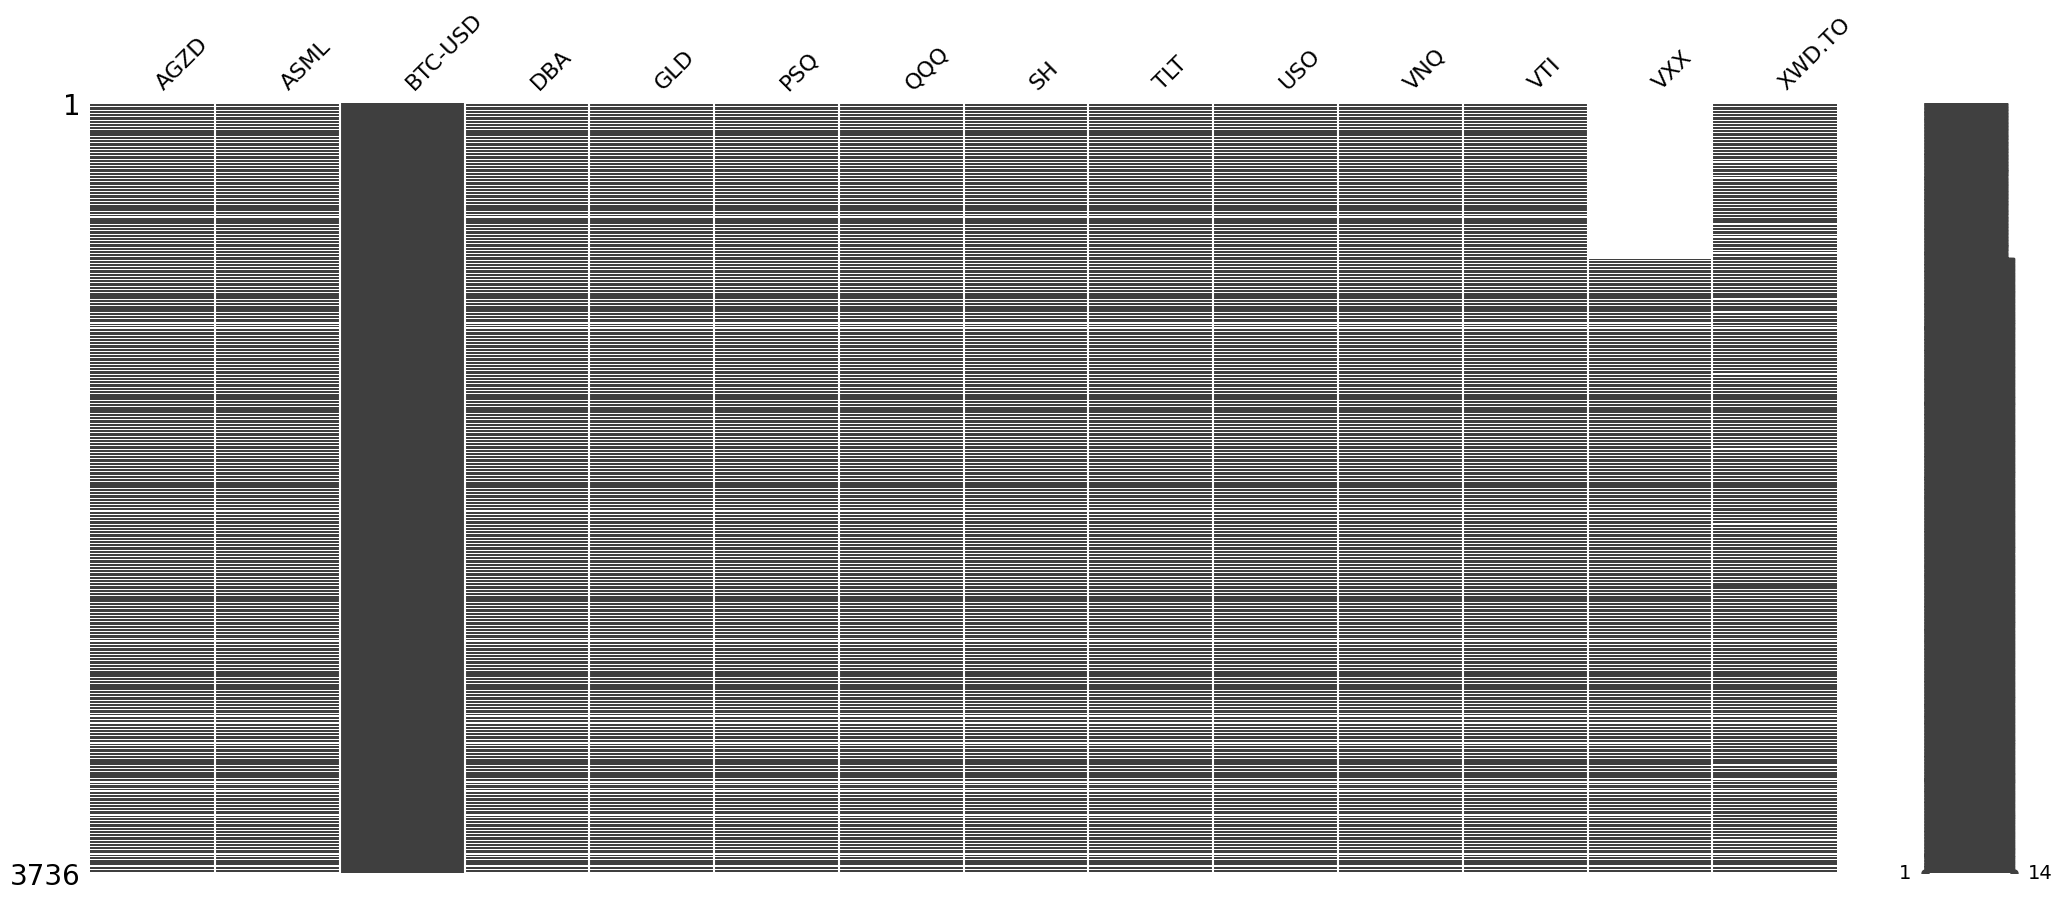

In [5]:
# TODO
mso.matrix(data)

Limpieza de datos

In [6]:
# TODO
data = data.dropna(axis = 1, how = "all")
data = data.dropna(axis = 0, how = "any")

<Axes: >

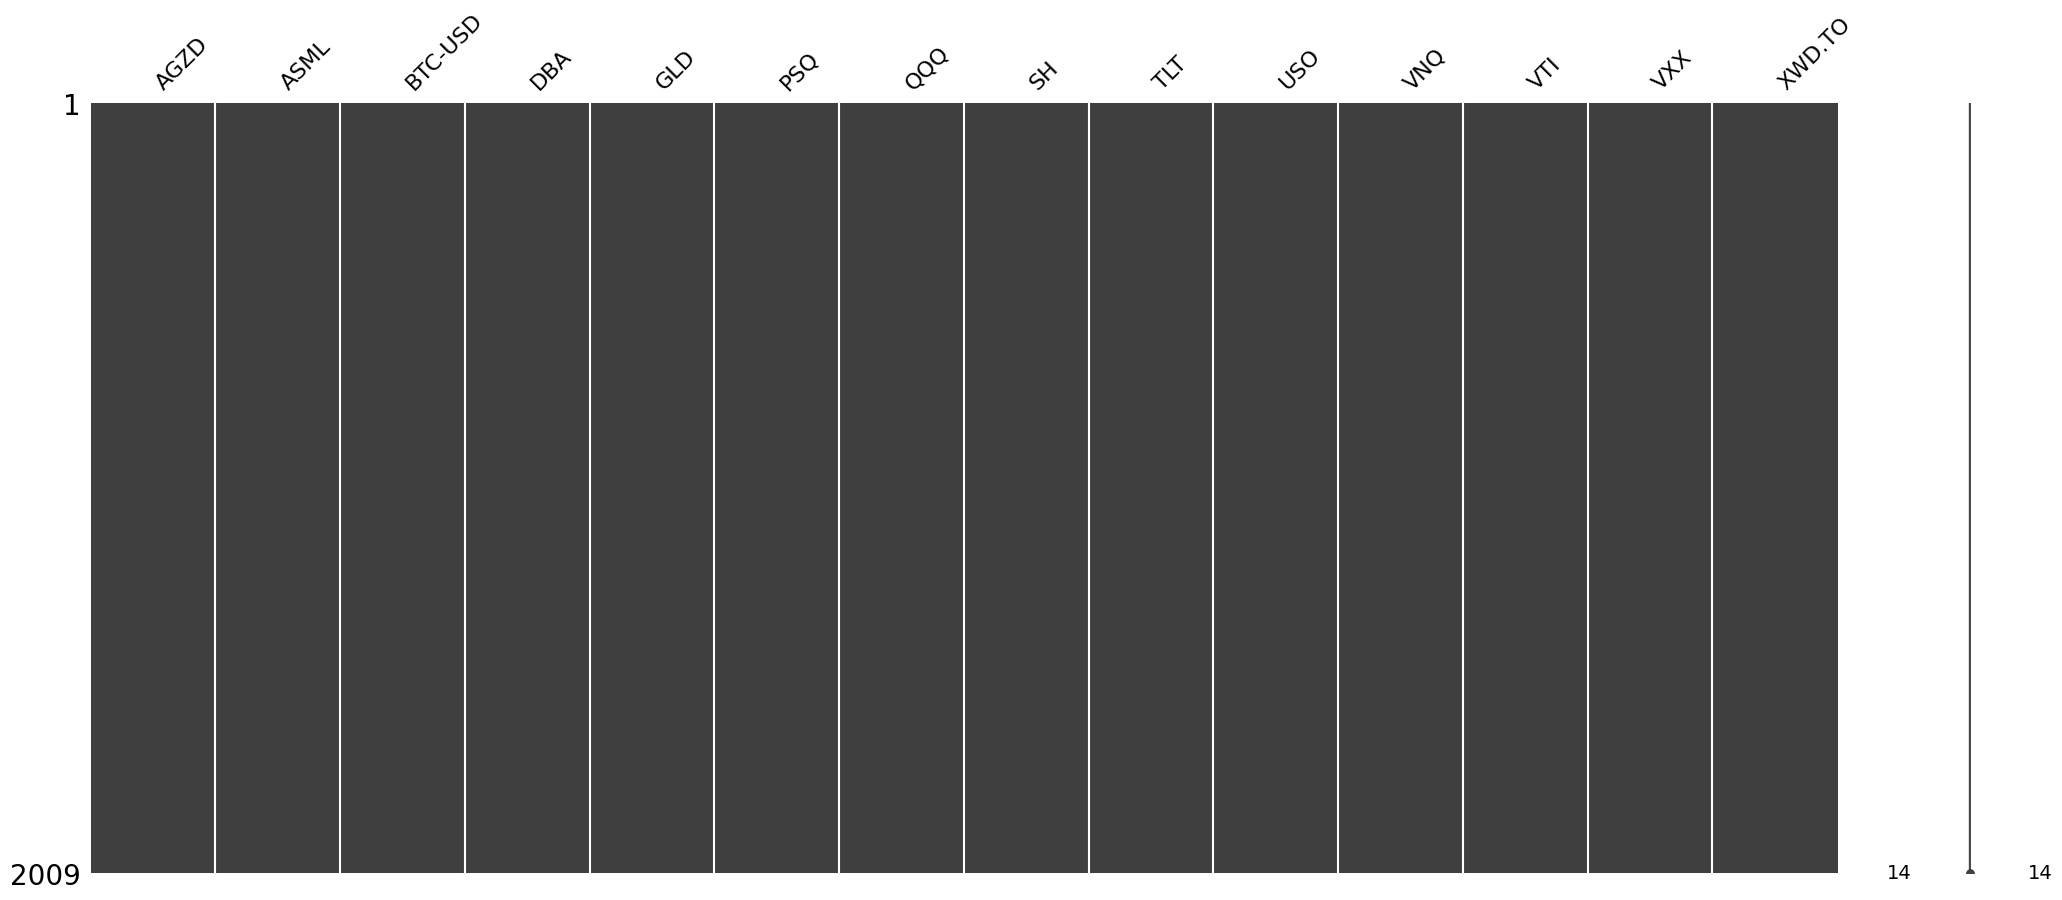

In [7]:
mso.matrix(data)


Alinea los dataframes de precios de los activos con el del índice.

In [8]:
# TODO
datos_alineados= pd.concat([data, data_idx], axis=1, join='inner')


Descripción básica de la estructura del dataframe de precios

In [9]:
# TODO
data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2009 entries, 2018-01-25 to 2026-03-24
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   AGZD     2009 non-null   float64
 1   ASML     2009 non-null   float64
 2   BTC-USD  2009 non-null   float64
 3   DBA      2009 non-null   float64
 4   GLD      2009 non-null   float64
 5   PSQ      2009 non-null   float64
 6   QQQ      2009 non-null   float64
 7   SH       2009 non-null   float64
 8   TLT      2009 non-null   float64
 9   USO      2009 non-null   float64
 10  VNQ      2009 non-null   float64
 11  VTI      2009 non-null   float64
 12  VXX      2009 non-null   float64
 13  XWD.TO   2009 non-null   float64
dtypes: float64(14)
memory usage: 235.4 KB


Desripción estadística básica de los precios

In [10]:
# TODO
data.describe()

Ticker,AGZD,ASML,BTC-USD,DBA,GLD,PSQ,QQQ,SH,TLT,USO,VNQ,VTI,VXX,XWD.TO
count,2009.000000,2009.000000,2009.000000,2009.000000,2009.000000,2009.000000,2009.000000,2009.000000,2009.000000,2009.000000,2009.000000,2009.000000,2009.000000,2009.000000
mean,19.161830,555.943309,38540.930976,18.270532,191.961702,69.009733,331.311557,61.740844,102.935832,72.544958,76.346570,202.342007,838.746693,66.696198
std,1.495739,292.181283,32535.520882,4.340903,74.351483,35.276392,134.881648,21.183109,18.122420,22.931705,11.250676,63.181826,914.349461,19.618682
min,16.863871,135.028580,3242.484863,11.612879,111.099998,29.000340,137.336334,35.400002,74.837906,17.040001,45.707424,102.467781,25.750000,39.245560
25%,18.145309,272.011230,9525.363281,14.656062,147.660004,40.737427,203.570938,45.187916,87.641014,63.200001,67.772240,141.912598,59.950001,49.644989
50%,18.489424,591.026367,28680.537109,17.481089,172.029999,55.207783,314.002686,52.830723,96.142944,73.199997,75.789078,197.210800,371.839996,62.877468
75%,20.316483,730.832520,60308.539062,20.817495,199.710007,102.980988,427.271027,84.045776,118.217064,87.040001,87.343063,244.920532,1628.800049,80.068733
max,22.559999,1526.510010,124752.531250,27.392115,495.899994,153.886826,634.951965,112.096428,144.897598,128.639999,99.132202,343.269989,4416.000000,113.089996


Cálculo de los retornos logarítmicos

In [11]:
# TODO
rets = np.log(data / data.shift(1)).dropna()
rets

Ticker,AGZD,ASML,BTC-USD,DBA,GLD,PSQ,QQQ,SH,TLT,USO,VNQ,VTI,VXX,XWD.TO
Date,,,,,,,,,,,,,,
2018-01-26,-0.000208,0.027890,-0.007846,0.007972,0.000781,-0.015001,0.015209,-0.011307,-0.003715,0.013688,-0.003507,0.010404,0.000000,0.006166
2018-01-29,-0.001244,-0.012131,0.011127,0.001058,-0.005638,0.004923,-0.004867,0.006376,-0.006982,-0.009867,-0.013518,-0.006558,0.067111,-0.005368
2018-01-30,0.000208,-0.018751,-0.111325,0.001585,-0.004328,0.008254,-0.008265,0.011585,-0.005884,-0.016148,-0.007276,-0.010473,0.032266,-0.010219
2018-01-31,0.002071,0.013542,0.011295,-0.005825,0.006681,-0.003965,0.004141,-0.001397,0.005884,0.006182,0.017778,0.000346,0.003268,-0.003026
2018-02-01,-0.000414,-0.007617,-0.108458,0.008988,0.003285,0.008521,-0.008537,0.001048,-0.014599,0.019833,-0.021758,-0.000415,-0.051654,-0.002225
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-03-18,0.001332,-0.024772,-0.036884,0.010835,-0.032148,0.014739,-0.014038,0.013952,-0.005619,0.023534,-0.014895,-0.013860,0.080740,-0.012442
2026-03-19,0.000444,0.008245,-0.018884,0.002227,-0.042088,0.002859,-0.003165,0.002927,0.006076,-0.036066,-0.004032,-0.001781,-0.026590,-0.002058
2026-03-20,-0.000888,-0.036626,0.008684,-0.004459,-0.031034,0.019162,-0.018655,0.014768,-0.019156,0.034092,-0.031499,-0.015795,0.063112,-0.020526


Descripción estadística básica de los retornos

In [12]:
# TODO
rets.describe()

Ticker,AGZD,ASML,BTC-USD,DBA,GLD,PSQ,QQQ,SH,TLT,USO,VNQ,VTI,VXX,XWD.TO
count,2008.000000,2008.000000,2008.000000,2008.000000,2008.000000,2008.000000,2008.000000,2008.000000,2008.000000,2008.000000,2008.000000,2008.000000,2008.000000,2008.000000
mean,0.000127,0.001007,0.000914,0.000255,0.000573,-0.000718,0.000645,-0.000453,-0.000069,0.000046,0.000200,0.000461,-0.001954,0.000431
std,0.002398,0.025841,0.041067,0.008661,0.010458,0.015195,0.015231,0.012348,0.009916,0.025871,0.014147,0.012567,0.044784,0.010406
min,-0.022260,-0.190545,-0.464730,-0.049865,-0.108412,-0.125441,-0.127592,-0.098178,-0.069010,-0.291891,-0.195136,-0.120822,-0.231166,-0.102733
25%,-0.000912,-0.012278,-0.016386,-0.004882,-0.004463,-0.008703,-0.006135,-0.006404,-0.005986,-0.011818,-0.006138,-0.004645,-0.026422,-0.003794
50%,0.000000,0.001123,0.000969,0.000000,0.000637,-0.001152,0.001285,-0.000765,0.000131,0.001311,0.000743,0.000888,-0.006315,0.000710
75%,0.001331,0.016070,0.019666,0.005441,0.005862,0.006215,0.008620,0.004599,0.005745,0.013488,0.007265,0.006823,0.015892,0.005480
max,0.021936,0.143530,0.203046,0.029828,0.061647,0.108016,0.113356,0.108949,0.072502,0.154151,0.086147,0.096633,0.315250,0.085220


Visualización de los retornos

<Axes: xlabel='Date'>

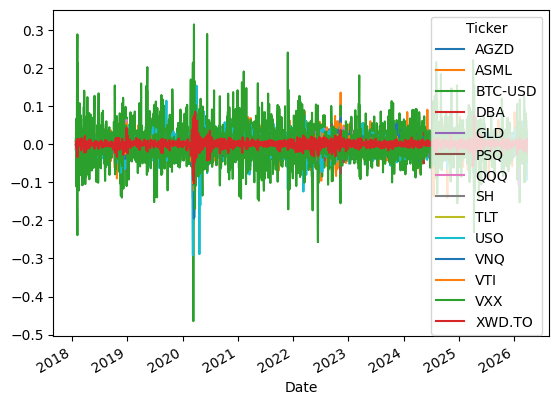

In [13]:
# TODO
rets.plot()

Visualización de las distribuciones de los retornos

<function matplotlib.pyplot.show(close=None, block=None)>

<Figure size 1600x800 with 0 Axes>

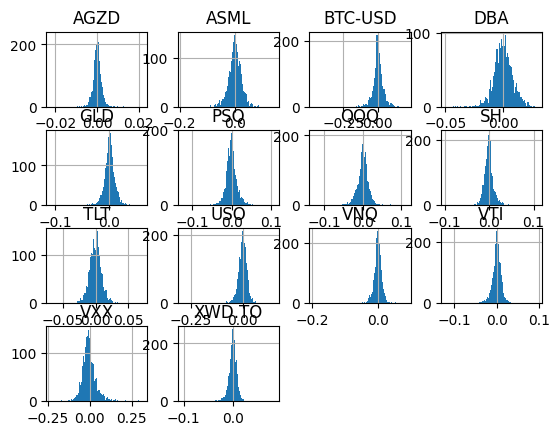

In [14]:
# TODO
plt.figure(figsize = (16,8))
rets.hist(bins = 100)
plt.show


Cálculo de skewness y kurtosis de los retornos

In [15]:
# TODO
kurtosis_retornos = rets.kurtosis()
print("Kurtosis de los activos")
print(kurtosis_retornos)

Kurtosis de los activos
Ticker
AGZD       14.736500
ASML        4.000761
BTC-USD    11.509026
DBA         2.182126
GLD         8.976595
PSQ         6.623309
QQQ         6.879987
SH         13.379333
TLT         4.802060
USO        20.684526
VNQ        24.532325
VTI        13.535045
VXX         5.990647
XWD.TO     17.125181
dtype: float64


In [16]:
 # TODO
ske_retornos = rets.skew()
print("skewness de los activos")
print(ske_retornos)

skewness de los activos
Ticker
AGZD      -0.391793
ASML      -0.338778
BTC-USD   -0.884938
DBA       -0.370660
GLD       -0.801503
PSQ       -0.075088
QQQ       -0.350435
SH         0.022220
TLT        0.062998
USO       -1.791845
VNQ       -1.578497
VTI       -0.588173
VXX        1.251633
XWD.TO    -0.548554
dtype: float64


Grafica los retornos de "USO" (United States Oil Fund (Petróleo, energía)) y "BIL" (SPDR Bloomberg 1-3 Month T-Bill)

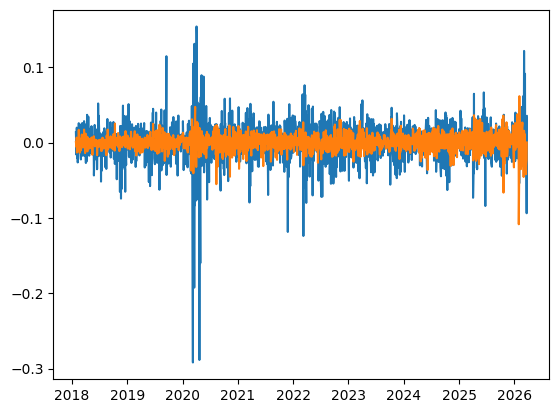

In [17]:
# TODO

plt.plot(rets[["USO","GLD"]])
plt.show()

Visualización de la relación por pares entre los retornos

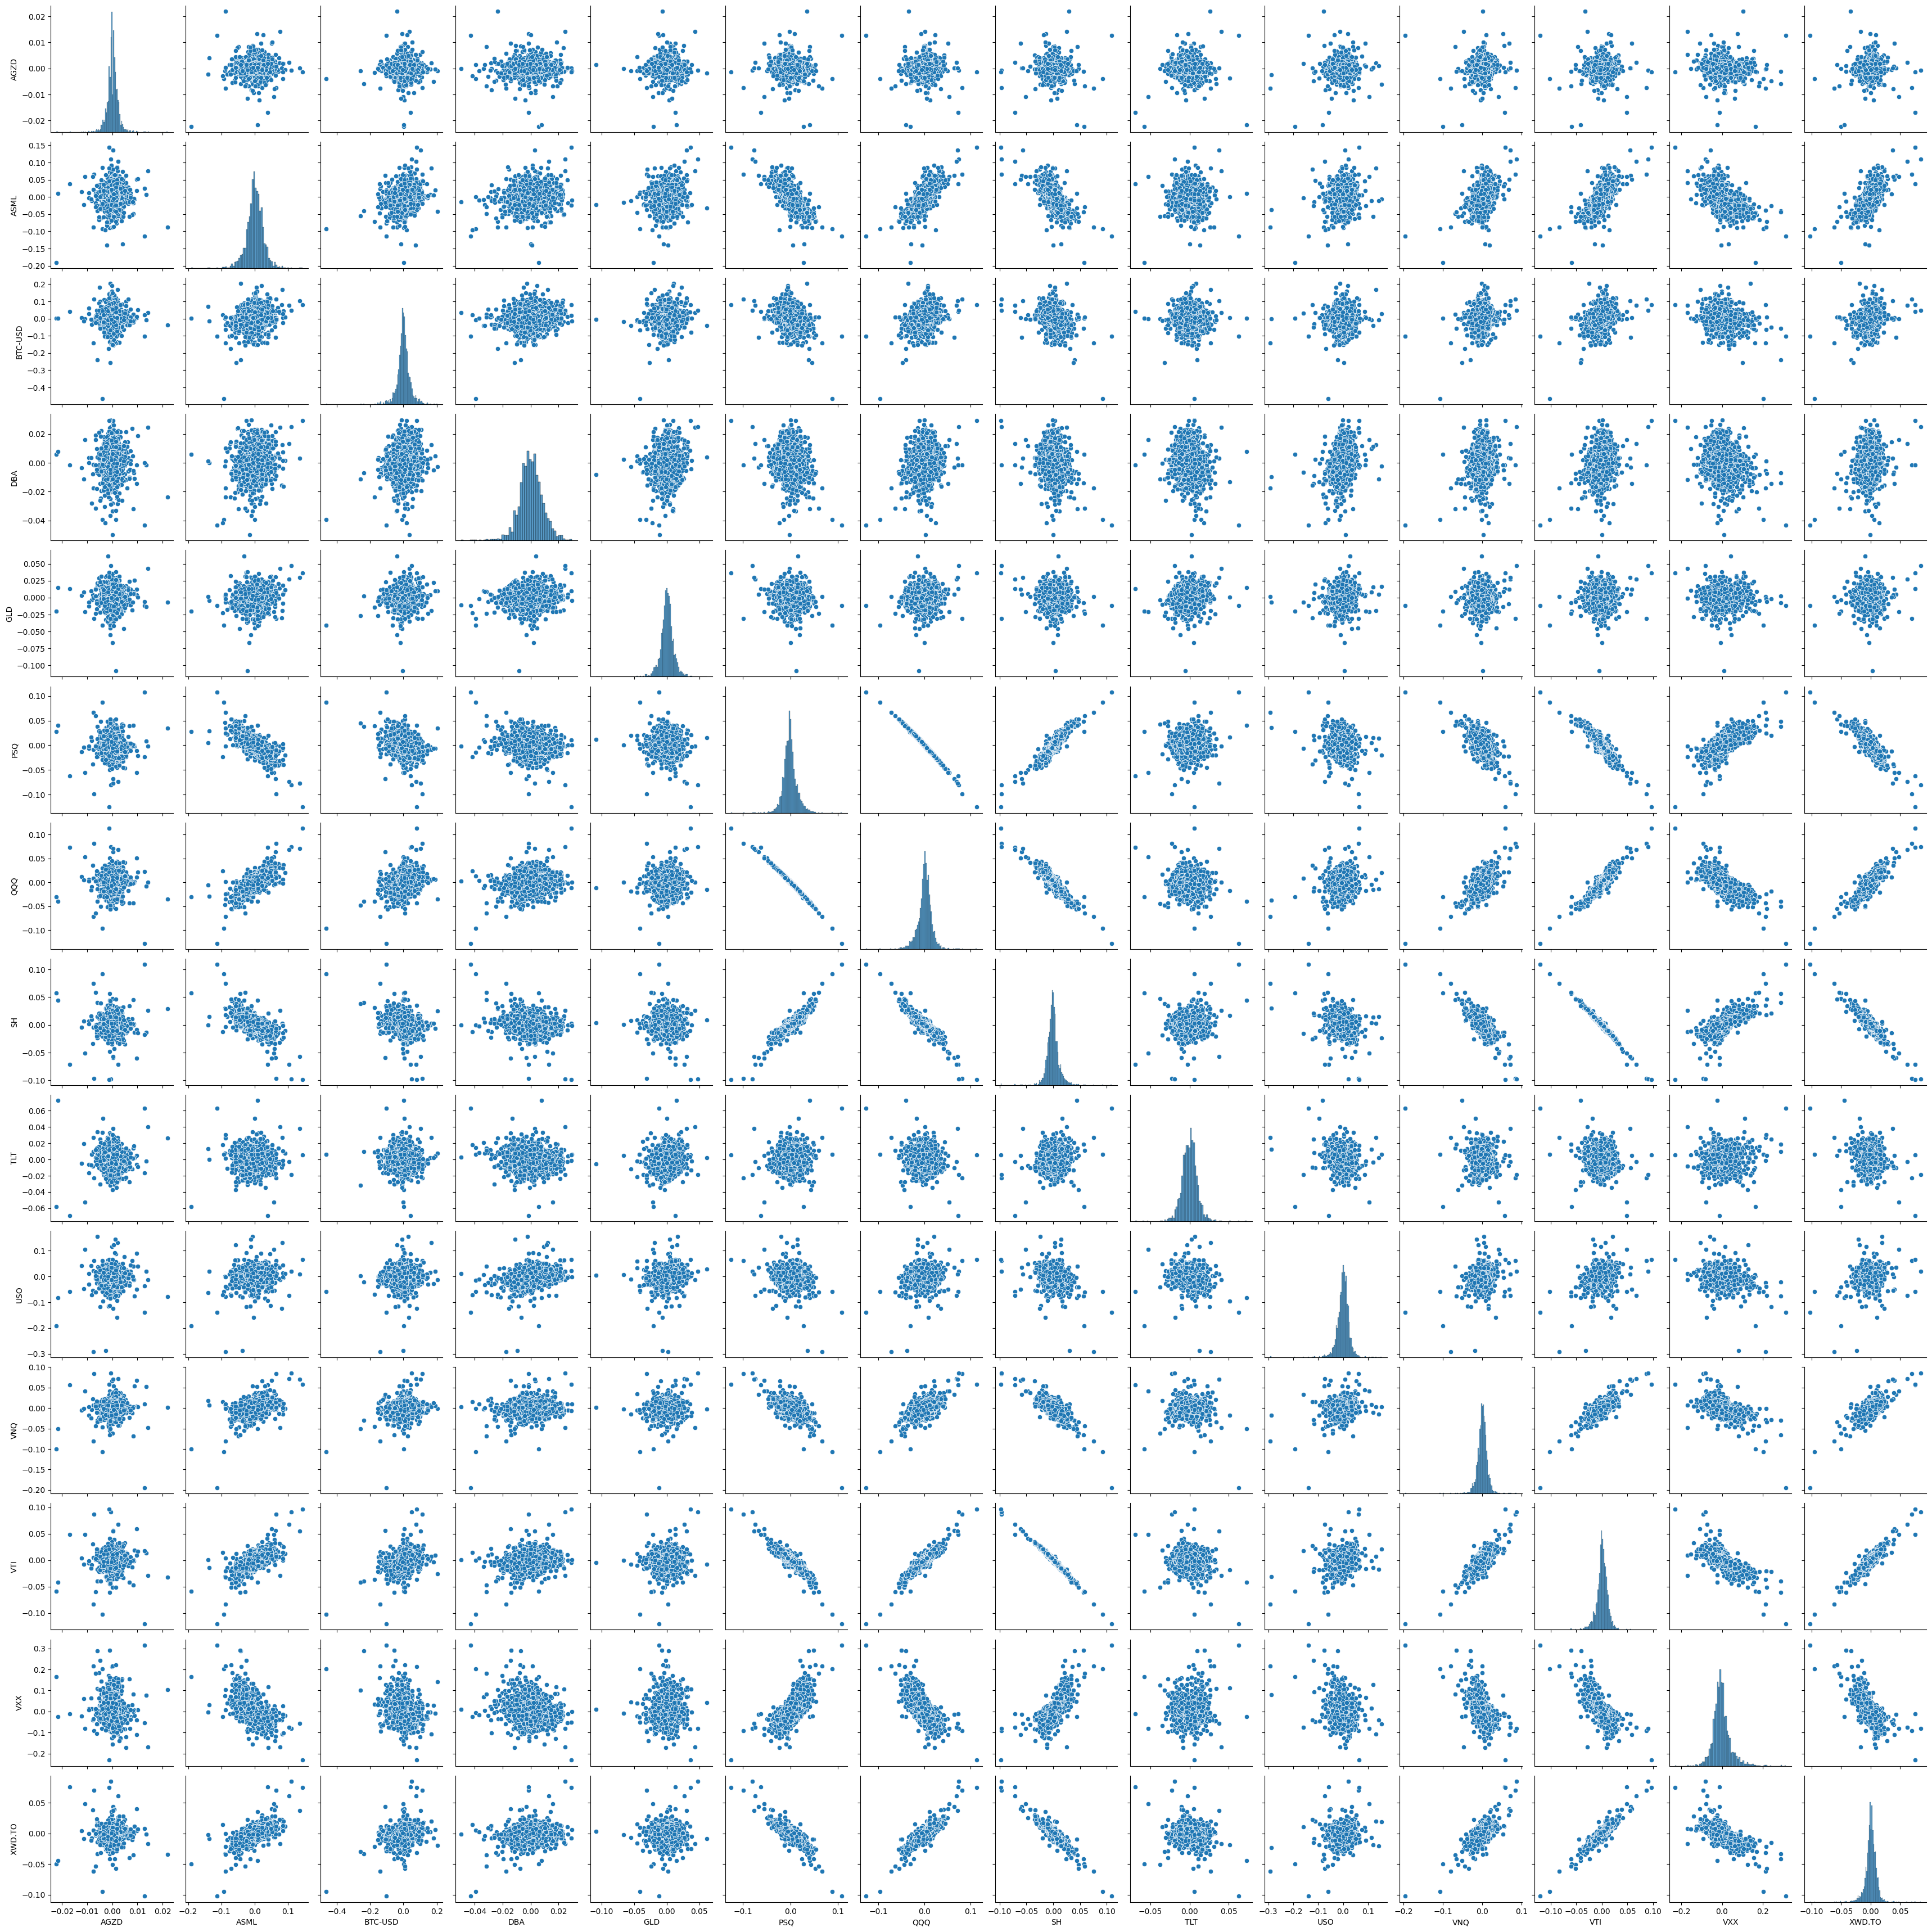

In [18]:
# TODO
sns.pairplot(rets)
plt.show()

Visualización de la matriz de correlación de los retornos

<Axes: xlabel='Ticker', ylabel='Ticker'>

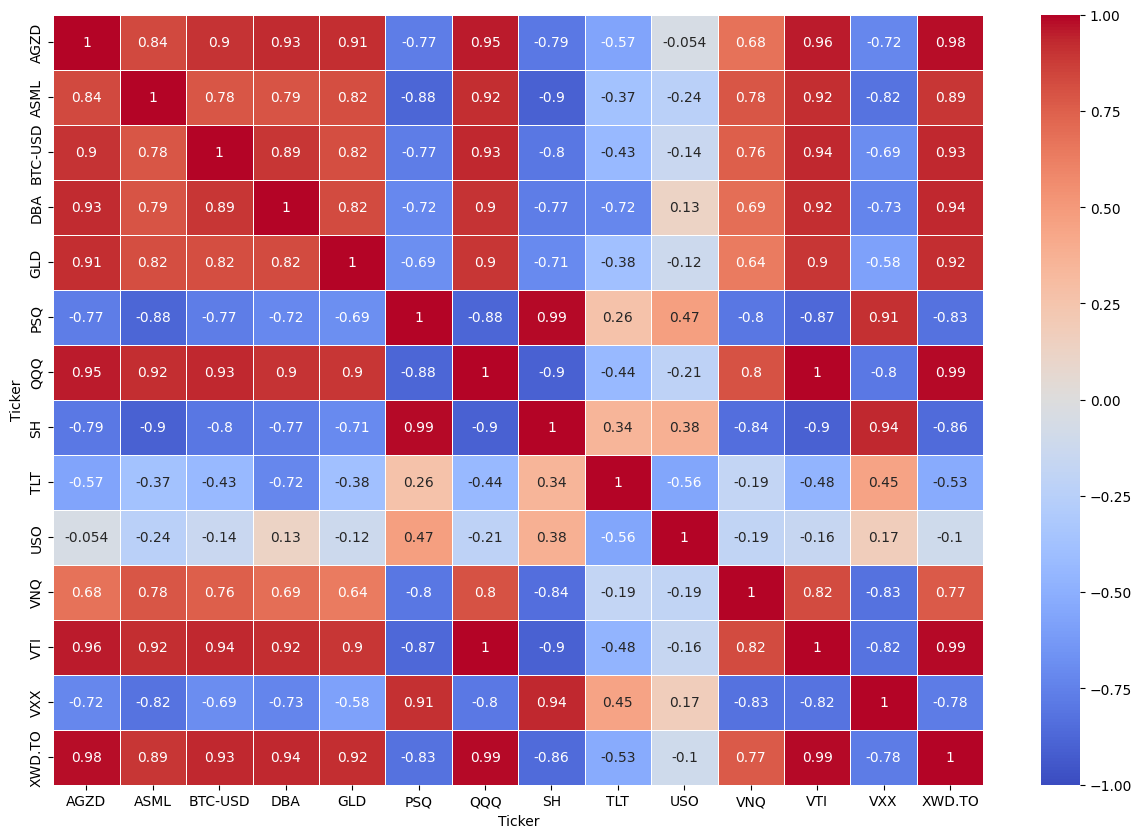

In [330]:

# TODO
matrix_corr = data.corr()

plt.figure(figsize=(15, 10))

sns.heatmap(matrix_corr,cmap = "coolwarm",vmin = -1, vmax = 1, linewidths= 0.5, annot = True)

## Ejercicio 2

Calcula los retornos del SPY

In [58]:
ret_idx = np.log(data_idx).diff().dropna()
ret_idx

,Adj Close
Date,
2016-01-05,0.001690
2016-01-06,-0.012695
2016-01-07,-0.024284
2016-01-08,-0.011037
2016-01-11,0.000990
...,...
2026-03-18,-0.014052
2026-03-19,-0.002467
2026-03-20,-0.014440


Crea una cartera equi-ponderada con todos los activos y calcula la serie de retornos.

In [59]:
pesos_eq = np.ones(data.shape[1]) / data.shape[1]
ret_cartera = data @ pesos_eq
ret_cartera.shape

ret_cartera = np.log(ret_cartera).diff().dropna()

Grafica los retornos acumulados de la cartera y del índice SPY.

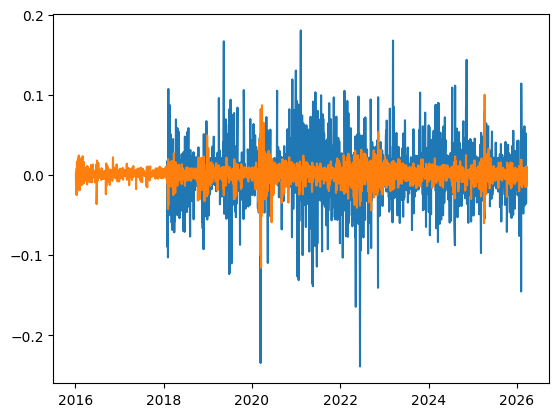

In [60]:
# TODO
plt.plot(ret_cartera)
plt.plot(ret_idx)
plt.show()

Calcula el retorno medio anualizado de la cartera y del índice SPY.

In [61]:
print(type(ret_idx))

<class 'pandas.core.series.Series'>


In [62]:
mu_idx = ret_idx.mean() * 252
mu_p = ret_cartera.mean() *252
print(f"Retorno medio anualizado del índice SPY: {mu_idx:.2%}")
print(f"Retorno medio anualizado de la cartera: {mu_p:.2%}")

Retorno medio anualizado del índice SPY: 13.21%
Retorno medio anualizado de la cartera: 20.68%


Calcula la volatilidad anualizada de la cartera y del índice SPY.

In [63]:
sigma_idx = ret_idx.std()*np.sqrt(252)
sigma_p = ret_cartera.std()*np.sqrt(252)
print(f"Volatilidad anualizada del índice SPY: {sigma_idx:.2%}")
print(f"Volatilidad anualizada de la cartera: {sigma_p:.2%}")

Volatilidad anualizada del índice SPY: 17.94%
Volatilidad anualizada de la cartera: 54.75%


Calcula el Ratio de Sharpe de la cartera y del índice SPY, asumiendo una tasa libre de riesgo del 0.0% anual.

In [65]:
rf = 0.0
sharpe_idx = (mu_idx - rf)/ sigma_idx
sharpe_p = (mu_p - rf) / sigma_p
print(f"Ratio de Sharpe del índice SPY: {sharpe_idx:.2f}")
print(f"Ratio de Sharpe de la cartera: {sharpe_p:.2f}")

Ratio de Sharpe del índice SPY: 0.74
Ratio de Sharpe de la cartera: 0.38


## Ejercicio 3

Calcula la cartera de máximo Ratio de Sharpe sin posiciones cortas, asumiendo una tasa libre de riesgo del 0.0% anual.

In [291]:
# TODO


# Forma de la Función: El ratio de Sharpe es una fracción con el riesgo (una raíz cuadrada) en el denominador.

# Al ser una funciion lineal en el numerador ( resta) y una funcion concava en el denominador (raiz cuadrada) no se cumple que el problema sea convezo, por eso se tien eque hacerun ajuste.

# Se tiene que transformar el problema


pesos_sharpe = cp.Variable(data.shape[1]) # 14

cov_matriz = rets.cov() # matriz de covarianzas
rentabilidades = rets.mean().values @ pesos_sharpe # son los retornos esperado de cada activo ( rentabilidades por pesos ) w1 * ret + w2 * ret .....

riesgo_sharpe = cp.quad_form(pesos_sharpe,cov_matriz) # riesgo --> al ser una raiz cuadrada no es una funcion convesa, es concava

restricciones = [ rentabilidades == 1  ,pesos_sharpe >= 0] # Igualamos el numerador a 1, para que al minimizar el riesgo (sigma) se maximize el ratio de sharpe ( esto es el ajuste)

# Se puede igualar a 1 el numerador por ser una funcion homogenea de grado 1, ya que el producto de un escalar por todos sus facotres no altera el resultado.

objetivo_sharpe = cp.Minimize(riesgo_sharpe) # Se minimiza el riesgo para conseguir el maximo ratio de sharpe (con 1)

problema_sharpe = cp.Problem(objetivo_sharpe,restricciones)

reuselto_sharpe = problema_sharpe.solve()

#NORMALIZAR PARA PODERE OPERAR CON ELLOS OTRA VEZ Y GRAFICAR


peso_norm = pesos_sharpe.value /pesos_sharpe.value.sum() # los valores de los pesos entre la suma de todos los valores

# la suma de todos da 1, que es el maximo de nuestra cartera, el 100%



In [292]:
# Verificar si se encontró una solución óptima
if problema_sharpe.status == cp.OPTIMAL:
    # Resultados
    print(f"Optimización exitosa. Valor óptimo: {problema_sharpe.value}")
else:
    print(f"No se pudo encontrar una solución óptima. Estado: {problema_sharpe.status}")
    if problema_sharpe.status == cp.INFEASIBLE:
        print("El problema es infactible. Las restricciones no pueden satisfacerse simultáneamente.")
    elif problema_sharpe.status == cp.UNBOUNDED:
        print("El problema es no acotado. La función objetivo puede mejorarse indefinidamente.")
    elif problema_sharpe.status == cp.OPTIMAL_INACCURATE:
        print("Se encontró una solución óptima pero con precisión reducida.")


Optimización exitosa. Valor óptimo: 115.74208337467513


Grafica los pesos de la cartera de máxima Ratio de Sharpe en un gráfico de barras.

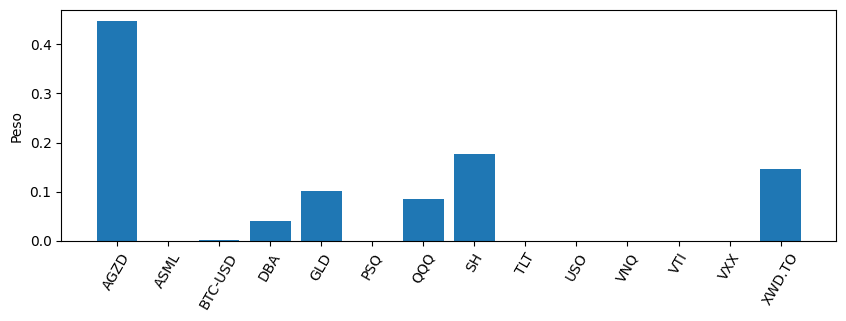

In [293]:
# TODO
num_act = data.shape[1]
plt.figure(figsize=(10, 3))
plt.bar(data.columns,peso_norm)
plt.xticks(range(num_act), data, rotation=60)
plt.ylabel("Peso")
plt.show()

Calcula la cartera de máxima rentabilidad sin posiciones cortas.

In [296]:
# TODO
matriz_cov = rets.cov()

pesos_max = cp.Variable(data.shape[1])

ret_max = rets.mean().values @ pesos_max
riesgo_max_rent = cp.quad_form(pesos_max,matriz_cov)
restricciones = [cp.sum(pesos_max) == 1 ,pesos_max >= 0]

objetivo_max = cp.Maximize(ret_max)

problema_max = cp.Problem(objetivo_max,restricciones)

resuelto = problema_max.solve()

In [297]:
# Verificar si se encontró una solución óptima
if problema_max.status == cp.OPTIMAL:
    # Resultados
    print(f"Optimización exitosa. Valor óptimo: {problema_max.value}")
else:
    print(f"No se pudo encontrar una solución óptima. Estado: {problema_max.status}")
    if problema_max.status == cp.INFEASIBLE:
        print("El problema es infactible. Las restricciones no pueden satisfacerse simultáneamente.")
    elif problema_max.status == cp.UNBOUNDED:
        print("El problema es no acotado. La función objetivo puede mejorarse indefinidamente.")
    elif problema_max.status == cp.OPTIMAL_INACCURATE:
        print("Se encontró una solución óptima pero con precisión reducida.")


Optimización exitosa. Valor óptimo: 0.0010067173338990524


Grafica los pesos de la cartera de máxima rentabilidad en un gráfico de barras.

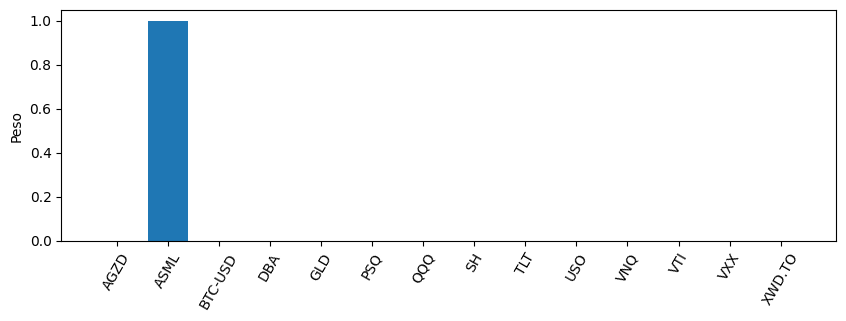

In [298]:
# TODO
plt.figure(figsize=(10, 3))
plt.bar(range(num_act), pesos_max.value)
plt.xticks(range(num_act), data, rotation=60)
plt.ylabel("Peso")
plt.show()

Calcula la cartera de mínima volatilidad sin posiciones cortas.

In [299]:
# TODO
matriz_cov = rets.cov()

pesos_min = cp.Variable(data.shape[1])

ret_min = rets.mean().values @ pesos_min
riesgo_min_vol = cp.quad_form(pesos_min,matriz_cov)
restricciones = [cp.sum(pesos_min) == 1 ,pesos_min >= 0]

objetivo_min = cp.Minimize(riesgo_min_vol)

problema_min = cp.Problem(objetivo_min,restricciones)

resuelto_min = problema_min.solve()


In [300]:
# Verificar si se encontró una solución óptima
if problema_min.status == cp.OPTIMAL:
    # Resultados
    print(f"Optimización exitosa. Valor óptimo: {problema_min.value}")
else:
    print(f"No se pudo encontrar una solución óptima. Estado: {problema_min.status}")
    if problema_min.status == cp.INFEASIBLE:
        print("El problema es infactible. Las restricciones no pueden satisfacerse simultáneamente.")
    elif problema_min.status == cp.UNBOUNDED:
        print("El problema es no acotado. La función objetivo puede mejorarse indefinidamente.")
    elif problema_min.status == cp.OPTIMAL_INACCURATE:
        print("Se encontró una solución óptima pero con precisión reducida.")


Optimización exitosa. Valor óptimo: 2.128991125870578e-07


Grafica los pesos de la cartera de mínima volatilidad en un gráfico de barras.

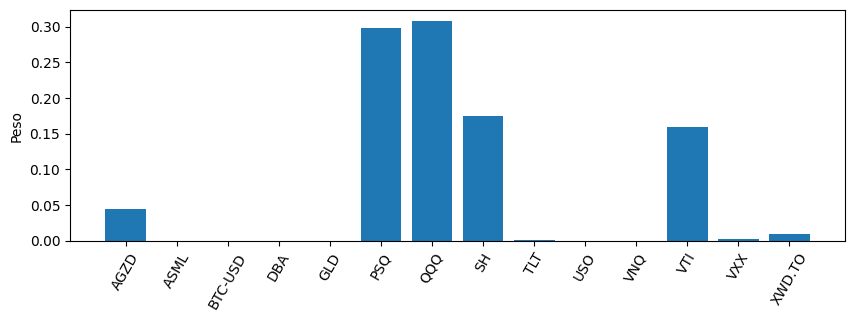

In [301]:
# TODO
# TODO
plt.figure(figsize=(10, 3))
plt.bar(range(num_act), pesos_min.value)
plt.xticks(range(num_act), data, rotation=60)
plt.ylabel("Peso")
plt.show()

Toma la cartera de máximo Ratio de Sharpe y la cartera de mínima volatilidad, y calcula 100 carteras como combinaciones lineales de estas dos. Calcula el retorno esperado anualizado y la volatilidad anualizada de cada una de estas carteras y grafícalas en el espacio rentabilidad-riesgo. Marca la posición de la cartera de máxima rentabilidad, la cartera de mínima volatilidad y la cartera de máximo Ratio de Sharpe en el mismo gráfico.

In [358]:
# TODO

retornos_esperados = rets.mean().to_numpy()

matriz_cov = rets.cov().to_numpy() # matriz de covarianza a numpy para trabajar con ella

min_riesgo = np.array([np.sqrt(riesgo_min_vol.value), ret_min.value]) # Los valores del riesgo y la rentabilidad de la certera de minimo riesgo

imax = np.argmax(rets.mean(axis=0)) # en que posicion esta el activo con la media deretornos mas alta (ASML  como hemos visto antes en la de maxima rentabilidad)

riesgos_lst = np.linspace(min_riesgo[0], np.sqrt(matriz_cov[imax, imax]), num=100) # 100 carteras equiponderadas desde:

# min_riesgo[0] : la volatilidad de la cartera de minima volatilidad
# np.sqrt(matriz_cov[imax, imax]: el riesgo del activo que  tiene mas rentabilidad
# ESTO ES PORQUE EN LA DIAGONAL DE LA MATRIZ DE COVARIANZA ESTA LA VARIANZA DE CADA ACTIVO, POR ESO SE HACE LA RAIZ CUADRADA
# num = 100: 100 carteras equiponderadas

retornos_lst= []
pesos_lst = []

for risk in riesgos_lst:
   peso_por_cartera = cp.Variable(data.shape[1])
   retorno = cp.Maximize(retornos_esperados.T @ peso_por_cartera)

   riesgo = cp.quad_form(peso_por_cartera, matriz_cov)

   constrains = [cp.sum(1)== 1, peso_por_cartera >= 0, riesgo <= risk**2] # se pone riesgo <= risk**2 para asegurarnos de que el riesgo no supera a la varianza

   problem = cp.Problem(retorno,constrains)
   result = problem.solve()

   retornos_lst.append(retorno.value)
   pesos_lst.append(peso_por_cartera.value)

   ############################


Grafica los retornos acumulados de la cartera equi-ponderada, la cartera de máximo Ratio de Sharpe y del índice SPY.

In [ ]:
# TODO
   ############################


## Ejercicio 4


Filtra los retornos del índice entre las fechas del 1 de enero de 2021 y el 31 de diciembre de 2022.

In [500]:
# TODO
tickers = ["SPY"]
data_idx = yf.download(tickers,  start = "2016-01-01", end = "2026-03-25", auto_adjust= True)["Close"]

data_idx.index = pd.to_datetime(data_idx.index)

data_idx_filtro = data_idx.loc['2021-01-01':'2022-12-31']

ret_idx_spy = np.log(data_idx_filtro / data_idx_filtro.shift(1)).dropna()


[*********************100%***********************]  1 of 1 completed


Grafica los retornos acumulados en el período.

<Axes: xlabel='Date'>

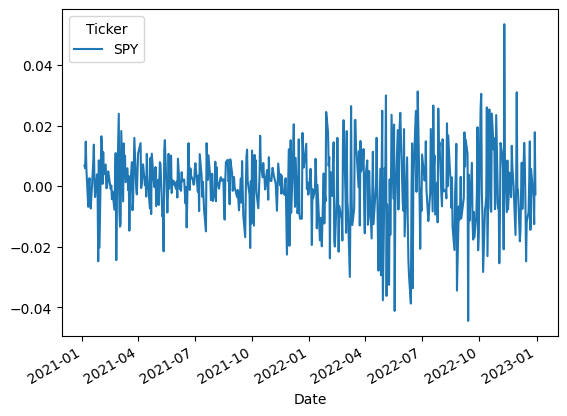

In [501]:
# TODO
ret_idx_spy.plot()

Calcula la Beta del CAPM de Apple (AAPL) con respecto al índice SPY en el período filtrado.

In [525]:
# TODO

precios_apple = yf.download("AAPL",start = "2021-01-01", end = "2022-12-31", auto_adjust=True)["Close"]

rendimiento_apple = np.log(precios_apple).diff().dropna()

x = ret_idx_spy
y = rendimiento_apple
x_sm = sm.add_constant(x)

modelo = sm.OLS(y,x_sm).fit()


[*********************100%***********************]  1 of 1 completed


In [526]:
print(modelo.summary())

                            OLS Regression Results                            
Dep. Variable:                   AAPL   R-squared:                       0.680
Model:                            OLS   Adj. R-squared:                  0.679
Method:                 Least Squares   F-statistic:                     1061.
Date:                Sat, 28 Mar 2026   Prob (F-statistic):          1.08e-125
Time:                        18:47:45   Log-Likelihood:                 1552.8
No. Observations:                 502   AIC:                            -3102.
Df Residuals:                     500   BIC:                            -3093.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0001      0.000     -0.283      0.7

Divide los retornos del índice en dos tramos:
1. Desde el 1 de enero de 2021 hasta el 31 de diciembre de 2021.
2. Desde el 1 de enero de 2022 hasta el 31 de diciembre de 2022.

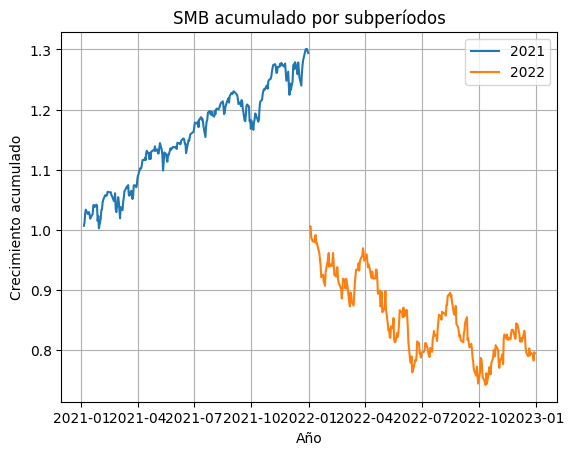

In [527]:
# TODO

ret_idx_pre22 = ret_idx_spy.loc[:"2021-12-31"]
ret_idx_post22 = ret_idx_spy.loc["2022-01-01":]


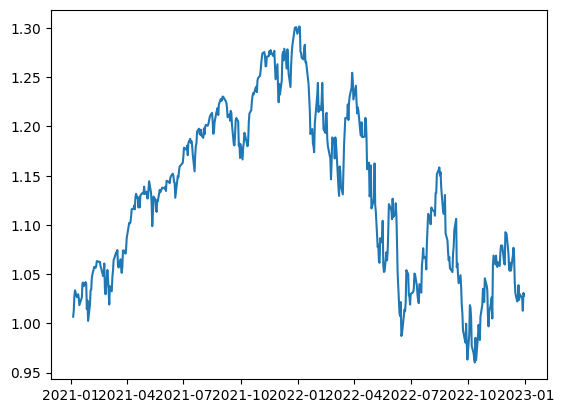

In [522]:
plt.plot((1+ret_idx_spy).cumprod())
plt.show()

Grafica los retornos acumulados de cada tramo.

In [ ]:
# TODO
plt.figure()
plt.plot((1 + ret_idx_pre22).cumprod(), label="2021")
plt.plot((1 + ret_idx_post22).cumprod(), label="2022")
plt.legend()
plt.title("SMB acumulado por subperíodos")
plt.xlabel("Año")
plt.ylabel("Crecimiento acumulado")
plt.grid(True)
plt.show()


Calcula la Beta del CAPM de Apple (APPL) con respecto al índice SPY en cada tramo.

In [ ]:
# TODO

In [ ]:
# TODO

In [ ]:
# TODO

## Ejercicio 5


Descarga los datos de Fama & French correspondientes al año 2025.

In [ ]:
# TODO


Descarga los datos del fondo con ticker "BLCR"

In [ ]:
# TODO

¿Qué tipo de fondo es "BLCR"? ¿Grandes o pequeñas empresas?

In [ ]:
# TODO

¿Y el fondo "IJR"? ¿Grandes o pequeñas empresas?

In [ ]:
# TODO